# Building our own Neural Network (pt. 1)
___
In this script we will build our own *home-made* neural network **WITHOUT** the help of the `scikit-learn` package's model. We will train our network using **backpropagation** and **gradient descent**, as is customary in neural networks. Backpropagation and gradient descent are closely related, but there is an important difference:  
+ **Gradient descent** is the optimization algorithm used to *minimize the loss*.
+ **Backpropagation** is the differentiation algorithm used to *compute the gradients*.

Going through this notebook will give you a better understanding of what these fancy graphical representations of neural networks really mean in terms of math and programming. For simplicity, we omit any bias terms, i.e., constant-value features in the input or hidden layers.

We will look at a classification example with only two input features, a single hidden layer with $n_Z$ hidden nodes, and a single output. The code is flexible with respect to the number of hidden nodes, so you can adjust them to see how the results change with more or less nodes in the hidden layer. When training the network, we will actually use stochastic gradient descent rather than gradient descent. Stochastic gradient descent is a special case of gradient descent. The idea is to compute the gradient using only a random subsample of the data instead of the full dataset. This has three main advantages:
1. It is typically quicker to reach a *good* result.
2. It is less likely that we end up getting stuck in a local minimum.
3. It slightly simplifies the code.

As you will see, neural networks entail a lot of matrix multiplications, so hopefully your linear algebra is up-to-date!

Note that this way of building a neural network is purely pedagogical. There is no chance that you would actually build your own neural network in a practical scenario. You would simply implement a network using one of the many deep learning packages in Python (see the first notebook *Introduction to Python*, for links to some of these packages).

___
## Data pre-processing

In [1]:
# Import necessary packages
import cmocean # Nice colormaps
import numpy as np # Numerical computation package
import pandas as pd # Dataframe package
import matplotlib.pyplot as plt # Plotting package
np.random.seed(1) # Set the random seed for reproduceability

Once again, will work with the WDBC dataset. There is nothing new here, this is very similar to what we did in the notebook on perceptrons.

In [2]:
# Read in the WDBC dataset
wdbc = pd.read_csv("data/wdbc.csv")
# Keep only necessary columns: the diagnosis, the perimeter, and the severity of concave portions
# of the cell nucleus
wdbc = wdbc[["perimeterM", "concaveM", "diagnosis"]]
wdbc # Display the dataset

,perimeterM,concaveM,diagnosis
0,122.80,0.14710,M
1,132.90,0.07017,M
2,130.00,0.12790,M
3,77.58,0.10520,M
4,135.10,0.10430,M
...,...,...,...
564,142.00,0.13890,M
565,131.20,0.09791,M
566,108.30,0.05302,M
567,140.10,0.15200,M


### 🙀 🤯 Standardization

First, we will begin by preprocessing the data. **This is an absolute must for neural networks**, even when working with a library instead of your own *home-built* network, preprocessing your data (usually via standardizing or normalizing) is key!

But why is it so important especially for neural networks as opposed to other statistical models? The answer lies in **gradient descent**. Let us consider standardizing. In truth, it's not some neural network specific architecture that makes it so important to standardize but simply the application of gradient descent. To see why, consider the following example.

Say that we have two features, ${x}_1$ and ${x}_2$ for every observation $i=1,\ldots, n$, and we are trying to find the weights $w_1$, $w_2$ which minimize the emprical risk defined with the squared loss $\ell_{\rm sq}$, that is $\widehat{L}_n(f_{w}) = \frac{1}{n} \sum_{i=1}^n (y^{(i)} - w_1 x_1^{(i)} - w_2 x_2^{(i)})^2$. So just as we did in some previous notebooks. Recall, that the weight updates are then given by:

\begin{align}
w_1 &\leftarrow w_1 - \eta \frac{\partial \widehat{L}_n(f_{w})}{\partial w_1} \\
w_2 &\leftarrow w_2 - \eta \frac{\partial \widehat{L}_n(f_{w})}{\partial w_2} 
\end{align}

which is equivalent to

\begin{align}
w_1 &\leftarrow w_1 - \eta \frac{1}{n} \sum_{i=1}^n (y^{(i)} - w_1 x_1^{(i)} - w_2 x_2^{(i)}) (-x_1^{(i)}) \\
w_2 &\leftarrow w_2 - \eta \frac{1}{n} \sum_{i=1}^n (y^{(i)} - w_1 x_1^{(i)} - w_2 x_2^{(i)}) (-x_2^{(i)}).
\end{align}

The important part of this equation is the last one. The updates on the weight $w_1$ are **scaled** by the values of the feature $x_1$, and the same happens for the weights $w_2$ with the features $x_2$.

Consider the iris example, where $x_1$ was the sepal width in centimeters, and $x_2$ the sepal length in centimeters. Both values in centimeters are on a somewhat similar scale, so this is not a problem. Consider, however, what would happen if instead we were to use the the sepal width in nanometers? Suddenly, our $x_1$ would be on average around 10 million times larger than the $x_2$ and the weight updates of $w_1$ would completely dominate the learning rate! So in the end, we would be dealing with a learning procedure where either $w_1$ has crazy explosive updates or $w_2$ nearly doesn't move, this would make it very hard for our network to converge!

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
# Create our features and label data
X = np.array(wdbc[["perimeterM", "concaveM"]])
y = np.array(wdbc["diagnosis"] == "M")

In [5]:
# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
# Quick verification that our mean and std are (0, 1)
print(X.mean(axis=0).round(5))
print(X.std(axis=0))

[-0. -0.]
[1. 1.]


___
## Training the neural network

There are a few parameters we need to define before we can start with training the network:

+ $d$, the number of nodes in the input layer (number of features we have)
+ $s_l$, the number of nodes in the hidden layer $l$.
+ The number of **epochs**. Recall that with gradient descent, we have to specify *how long* we want our procedure to repeat. This is encoded in the number of epochs.
+ $\eta$, the learning rate, a small number which governs *how large* our weight updates will be at each update step

In [7]:
# Initialize some parameters
n, d = X.shape # Number of observations and features
sl = 3 # Number of hidden nodes
epochs = 100 # Number of training epochs
eta = 0.01 # Learning rate
init_range = [-.5, .5] # The range of our uniform distribution for weight initialization

___
### 🙀 🤯 Mathematical formulation

Before we go ahead and write the code, it's a good idea to review how a neural network is supposed to work from a mathematical perspective. First, let's go over the individual pieces of our network:  
+ $n$, the number of observations ($n=569$) in our case
+ $d$, the number of features ($d=2$) in our case
+ $s_l$, the number of nodes in the hidden layer $l=1$
+ $\mathbf{X}$, a $n \times d$ matrix of data inputs
+ $\mathbf{y}$, a column vector of targets with $n$ elements
+ $W_1$ ($\Theta_1$ in the slides), a $s_l \times d$ a weight matrix which *passes* the input data to the hidden layer (before activation)
+ $\sigma_1: \mathbb{R} \to \mathbb{R}$, an activation function, applied element-wise to the output of the first layer
+ $W_2$ ($\Theta_2$ in the slides), a $1 \times s_l$ a weight matrix (or a column vector) which *passes* the data from hidden layer to the output layer (before activation)
+ $\sigma_2: \mathbb{R} \to \mathbb{R}$, an activation function, applied element-wise to the output of the second layer

Putting all these elements together, the neural network $f : \mathbb{R}^{N \times d} \to \mathbb{R}^N$ can be expressed as (see slide 23):

$$f(\mathbf{X}) = \sigma_2(\sigma_1(\mathbf{X} {W}_1^\top){W}_2^\top)$$

Notice that if you want to obtain the output of the neural network for each separate observation with index $i$ it is easier to write

$$f(\mathbf{x}^{(i)}) = \sigma_2(W_2 \sigma_1({W}_1 \mathbf{x}^{(i)}))$$

which defines $f : \mathbb{R}^{d \times 1} \to \mathbb{R}$ (just for one $d$-long feature of $i$-th observation. 

Can you recall what we are training in this neural network? That's right, the weights $W_1$ and $W_2$. That's all, everything else is *given* or *defined*. Of course, to train our network, we need to start with some values for $W_1$ and $W_2$. We will do so by randomly initializing each element in $\text{unif.}[-0.5, 0.5]$.
___



#### 🤔 Pause and ponder
Why is $W_1$ a $s_l \times d$ matrix and $W_2$ a $1 \times s_l$ matrix? Could we have chosen other dimensions? How does the dimension of $W_2$ change if the output dimension of the neural network is not 1?
___

In [8]:
# Initialize weight matrices
np.random.seed(2) # Set seed
W1 = np.random.rand(sl, d) # Randomly initialize W1
W1 = W1 * (init_range[1] - init_range[0]) - init_range[0] # Constrain to range
W2 = np.random.rand(1, sl) # Randomly initialize W2
W2 = W2 * (init_range[1] - init_range[0]) - init_range[0] # Constrain to range

___
#### 🤔 Pause and ponder
Do you see how the above weights relate to the graphical representation seen in class?
___

In [9]:
# We will use the sigmoid function as the activation function
sigmoid = lambda x: 1 / (1 + np.exp(-x))

Because we will use it a few times, we define a function for the **forward pass** of our network. Recall the mathematical formulation above, you will see that this function is nothing else but

$$f(\mathbf{X}) = \sigma_2(\sigma_1(\mathbf{X} {W}_1^\top){W}_2^\top)$$

Notice that if you want to obtain the output of the neural network for each separate observation with index $i$ it is easier to write

$$f(\mathbf{x}^{(i)}) = \sigma_2(W_2 \sigma_1({W}_1 \mathbf{x}^{(i)}))$$

which defines $f : \mathbb{R}^{d \times 1} \to \mathbb{R}$ (just for one $d$-long feature of $i$-th observation. 


#### <font style="color:green">**➡️ ✏️ TASK 1**</font>

Implement the forward pass through the network in a matrix form. Fill the gaps in the code below.

In [10]:
# Forward pass helper
def forward_pass(X, W1, W2):
    # Compute the matrix multiplication of the input layer
    Z_2 = X @ W1.T
    
    # Pass through the non-linear activation function
    A_2 = sigmoid(Z_2)
    
    # Compute the matrix multiplication of the hidden layer
    Z_3 = A_2 @ W2.T

    A_3 = sigmoid(Z_3)
    # Pass through the non-linear activation function 
    # (This should always be sigmoid for the output to be (0, 1))
    return A_3.flatten() # Transform the output back to a vector instead of Nx1 matrix

In [11]:
# This function, we will use to evaluate our predictions
# ⚠️ Look at the details of this function only after you have gone through the
# ⚠️ code with the training loop below. See the questions at the end of the script
def eval_predictions(X, y, W1, W2):
    # Use the forward_pass function defined above to compute our estimated probability
    prob = forward_pass(X, W1, W2)
    
    # To avoid log(0), clip the probability to not be exactly zero or one
    prob = np.clip(prob, 1e-8, 1-1e-8)
    # Calculate the loss function (negative log-likelihood in this case)
    loss = - np.sum(y * np.log(prob) + (1 - y) * np.log(1 - prob))

    # Convert probabilities into (0, 1) prediction
    pred = (prob >= 0.5).astype(int)
    
    # Compute number of misclassification
    misclassifications = np.mean(pred != y)
    
    # Output results as a dictionary
    return {
        "loss": loss, 
        "misclassifications": misclassifications, 
        "prob": prob, 
        "pred": pred
    }

In [12]:
# Initializitation of lists for bookkeeping
loss_list = []
misclassification_list = []

# Create an array of indices (which we will shuffle later on) through which we 
# will iterate. This represent the index of the observations
indices = np.arange(n)

In [13]:
# Ignore this, we use it to print nicely without creating too many lines
from sys import stdout

#### <font style="color:green">**➡️ ✏️ Task 2**</font>

Code the backpropagation algorithm, filling the gaps below.

In [14]:
np.random.seed(2)  # Reset random seed for reproducibility

# Compute the initial loss and misclassifications BEFORE training
res = eval_predictions(X, y, W1, W2)

# Append to our result lists
loss_list.append(res["loss"])
misclassification_list.append(res["misclassifications"])

# Run the full training loop (iterate over the number of training epochs)
for epoch in range(epochs):
    # Reshuffle the indices
    np.random.shuffle(indices)
    
    # Iterate through each SINGLE data OBSERVATION
    for i in indices:
        # Extract features for ith observation (keeping as a column vector)
        Xi = X[i:i+1, :].T  # Transpose to make Xi a column vector
        yi = y[i]           # Extract label for ith observation
        
        # ----- Forward pass -----    
        # Hidden layer pre-activation
        Z_2 = W1 @ Xi
        # Hidden layer activation (using sigmoid)
        A_2 = sigmoid(Z_2)
        
        # Output layer pre-activation
        Z_3 = W2 @ A_2
        # Output layer activation (using sigmoid)
        A_3 = sigmoid(Z_3)
        
        # ----- Backward pass -----
        # Likelihood + sigmoid -> delta_L = A3 - yi     
        # Output layer error term
        delta3 = A_3 - yi
        
        # Hidden layer
        # delta2 = (W2^T @ delta3) ⊙ σ'(Z_2) = (W2^T @ delta3) * A_2 * (1 - A_2)
        delta2 = (W2.T @ delta3) * A_2 * (1 - A_2)
        
        # ----- Gradients (outer products) -----
        # ∂L/∂W2 = delta3 @ A2^T ;  ∂L/∂W1 = delta2 @ Xi^T
        grad_W2 = delta3 @ A_2.T                  # (s3,s2)
        grad_W1 = delta2 @ Xi.T                  # (s2,d)  
        
        
        # ----- Parameter updates -----
        # Update weights with learning rate
        W1 -= eta * grad_W1
        W2 -= eta * grad_W2
    
    # Evaluate the learning process and store the results into our lists
    res = eval_predictions(X, y, W1, W2)
    loss_list.append(res["loss"])
    misclassification_list.append(res["misclassifications"])    
    
    # Print the current status (ignore this part!)
    bar = "".join(["#" if epoch >= t * (epochs // 50) else " " for t in range(50)])
    stdout.write(f"\rEpoch: {epoch+1:>{int(np.floor(np.log10(epochs))+1)}}/{epochs} [{bar}]")


Epoch: 100/100 [##################################################]

Print out gradient values to make sure the training went well

In [15]:
print(res)
print(y)

{'loss': 108.98743617205844, 'misclassifications': 0.08084358523725835, 'prob': array([0.98695077, 0.97622118, 0.986494  , 0.92426794, 0.98520286,
       0.77948876, 0.96793515, 0.57474444, 0.9282033 , 0.85182246,
       0.33959034, 0.89350582, 0.98561715, 0.77591802, 0.90293629,
       0.88685096, 0.5430122 , 0.97806398, 0.98312192, 0.24501522,
       0.06286937, 0.00986338, 0.97079003, 0.9830019 , 0.97318418,
       0.9863114 , 0.94804297, 0.97307673, 0.95909031, 0.96802864,
       0.98593908, 0.13693492, 0.98408696, 0.97625267, 0.95128681,
       0.90584774, 0.58646836, 0.04348378, 0.13359129, 0.39887944,
       0.03336471, 0.11227012, 0.9836046 , 0.53060071, 0.28190645,
       0.98289256, 0.00642509, 0.73270137, 0.02835685, 0.08518873,
       0.01210989, 0.03017585, 0.01360497, 0.98313122, 0.21507611,
       0.01734853, 0.98071248, 0.91968057, 0.01316693, 0.00682166,
       0.00918854, 0.00699518, 0.94170246, 0.00979562, 0.55726927,
       0.95321493, 0.00860735, 0.01580735, 0.0201

___
## Evaluating the results
That's it, we can go ahead and look at the results of our own custom neural network!

Text(0.5, 1.0, 'Evolution of missclassification rate over training epochs')

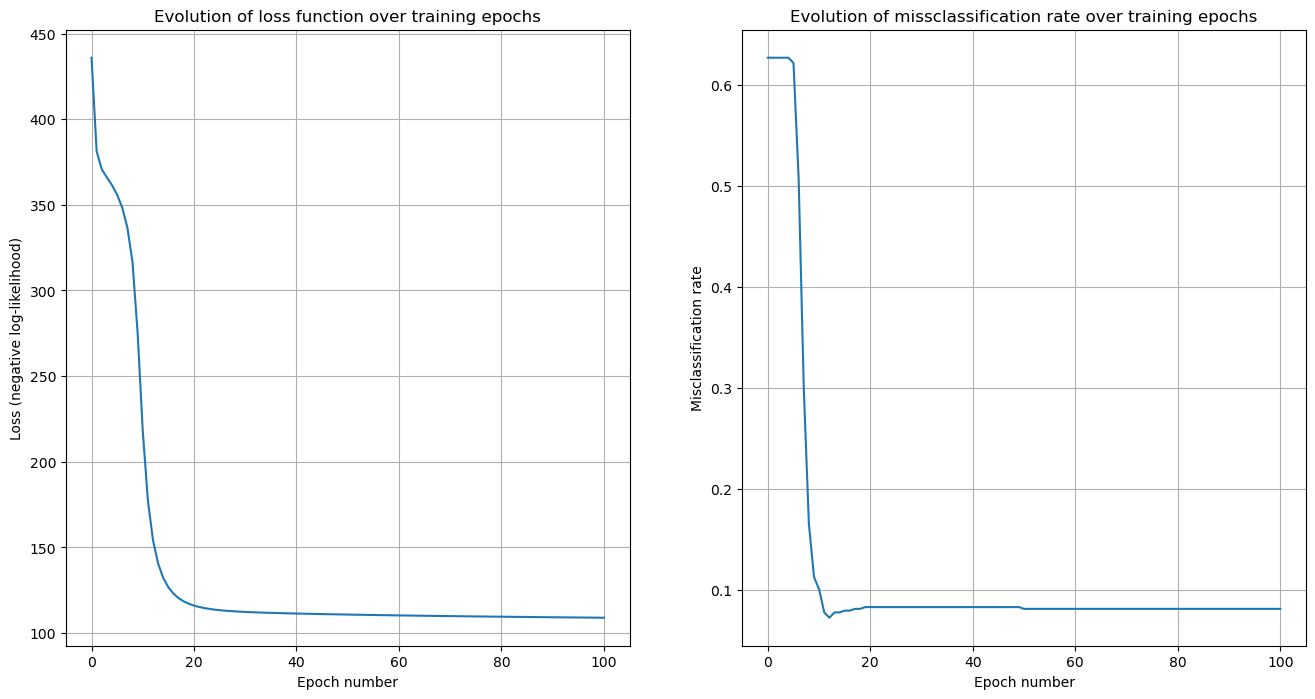

In [16]:
# Set up the canvas
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
# Plot the loss over the epochs (epoch 0 is before training!)
axs[0].plot(range(len(loss_list)), loss_list)
# Plot the misclassification rate over the epochs
axs[1].plot(range(len(misclassification_list)), misclassification_list)
# Add title, grid, axis labels
for ax in axs:
    ax.grid(True)
    ax.set_xlabel("Epoch number")
axs[0].set_ylabel("Loss (negative log-likelihood)")
axs[0].set_title("Evolution of loss function over training epochs")
axs[1].set_ylabel("Misclassification rate")
axs[1].set_title("Evolution of missclassification rate over training epochs")

Pretty neat! Our *home-built* neural network works as expected! It achieves a 90% correct classification rate in approximately 35 epochs and then the performance starts stagnating at around 60 epochs. Of course, as you well know, we shouldn't read too much into this, this is purely in-sample, but independent of the out-of-sample performance, our machinery works, which is the main takeaway.

We can also have a look at the weights to see what the final weights are (we use `pandas` for prettier table view).

#### <font style="color:green">**➡️ ✏️ Task 3**</font>

Pretty neat! Our *home-built* neural network works as expected! What level of correct classification rate it reaches and in how many epochs? When the performance starts stagnating? Of course, as you well know, we shouldn't read too much into this, this is purely in-sample, but independent of the out-of-sample performance, our machinery works, which is the main takeaway.

We can also have a look at the weights to see what the final weights are (use `pandas` for prettier table view).

In [17]:
# Display the weight matrix from the input layer to the hidden layer
pd.DataFrame(W1.T, columns=[f"Z{i}" for i in range(sl)], index=["X1", "X2"])

,Z0,Z1,Z2
X1,-0.845962,1.701904,1.396014
X2,-1.339057,1.742571,1.408467


In [18]:
# Display the weight matrix  from the hidden layer to the output layer
pd.DataFrame(W2.T, columns=["T"], index=[f"Z{i}" for i in range(sl)])

,T
Z0,-5.381495
Z1,2.780901
Z2,1.617770


___
## Visualizing the decision regions

Since our feature space is two dimensional, it's easy to *visualize the decision regions* of our neural network. Think about it: every data point can be represented on an $(x_1, x_2)$ plane, and, for every data point, we can make a prediction using our neural network. Combining this, we can create a grid of thinly spaced $(x_1, x_2)$ points, feed them to our neural network and plot them according to the output it suggests.

This is nice because it helps us understand the underlying relationship that was uncovered by our neural network. Recall how, during the perceptron class, we drew the perceptron separation line on the features plane. Do you think the neural network will also split the feature space using a line? Why, why not?

In [19]:
# Define granularity and limits of grids
npoints = 200
x1_lims = (X[:, 0].min() - .1, X[:, 0].max() + .1)
x2_lims = (X[:, 1].min() - .1, X[:, 1].max() + .1)

# Create the x1 and x2 arrays
x1 = np.linspace(*x1_lims, num=npoints)
x2 = np.linspace(*x2_lims, num=npoints)
preds = np.empty((npoints, npoints))

# Compute the predictions of our network for every single combination
for i in range(x2.shape[0]):
    for j in range(x1.shape[0]):
        # Create the 1x2 input
        xi = np.array([[x1[j], x2[i]]])
        # Compute the prediction of the network
        preds[i, j] = forward_pass(xi, W1, W2)

# Small trick to scale back values to their value before standardization
Xt = scaler.inverse_transform(np.array([x1, x2]).T)
x1, x2 = Xt[:, 0], Xt[:, 1]

/tmp/ipykernel_208/2847283737.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[i, j] = forward_pass(xi, W1, W2)


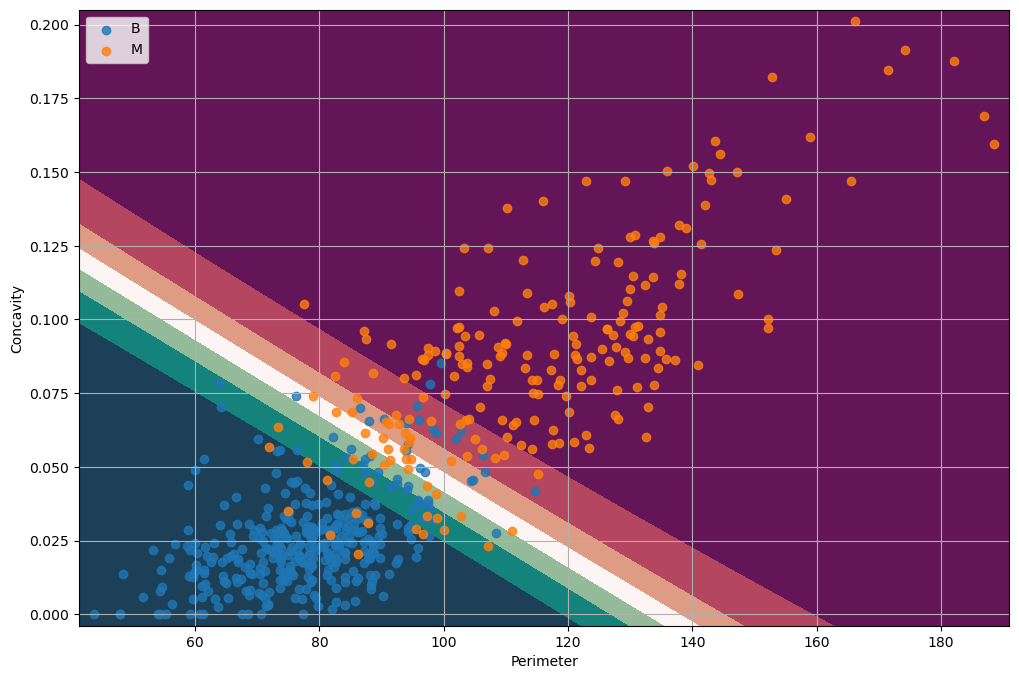

In [20]:
# Set up the canvas
fig, ax = plt.subplots(figsize=(12, 8))
# Add decision regions
ax.contourf(x1, x2, preds, cmap=cmocean.cm.curl)

# Add true data points
for diag in ["B", "M"]:
    subset = wdbc.loc[wdbc["diagnosis"] == diag]
    ax.scatter(subset["perimeterM"], subset["concaveM"], label=diag, alpha=0.8)
    
# Add grid, labels, etc.
ax.grid(True)
ax.set_xlabel("Perimeter")
ax.set_ylabel("Concavity")
ax.legend()
plt.show()

The benign tumors are shown in blue above and the malignant ones in orange. The color in the background are the decision regions of our neural network. We notice that the decision boundary is a straight line. The intensity of the color regions show *how sure* the neural network is in making the prediction, i.e. in the dark purple area in the top right, the network assigns a very high probability that the tumor is malignant while in the lower left, the probability is very low. Around the white band however, the probability is around 0.5. Of course, in the end, a tumor is always classified as either benign or malignant, but this helps us visualize where the predictions are more *unstable*.

___
### Additional Questions

#### <font style="color:green">**➡️ ✏️ Questions 4**</font>
Try playing around with the parameters. Change the hidden nodes, learning rate, number of epochs.

How do the results change? Do they get better or worse? How do the decision region change?

*Hint*: If you encounter an error, try changing some parameters back. A too high learning rate can cause your weights to explode and `numpy` won't be able to handle such large numbers (in particular when trying to exponentiate them!)

#### <font style="color:green">**➡️ ✏️ Questions 5**</font>

Carefully inspect the code of `eval_predictions(...)` and `forward_pass(...)`.

+ Why do we compute the `forward_pass` manually again in the training loop? Is there a difference?
+ Do we need `eval_predictions` to train our network?

Discuss with your classmates and try to explain the code to each other!